Extracting and parsing dataset from archive. This may take a moment...
Sanitizing text data...


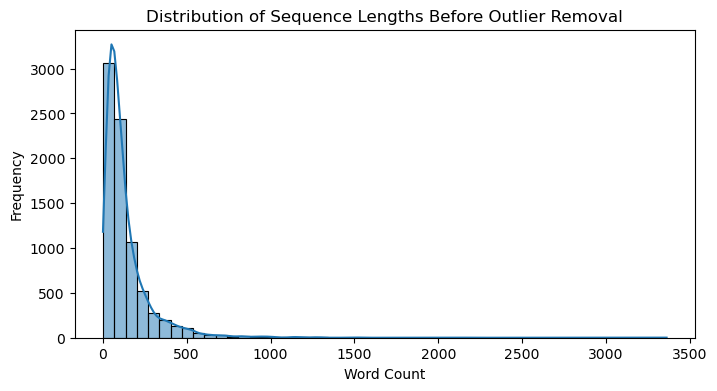

Original dataset size: 8000
Dataset size after outlier removal: 7999


,review,clean_review,sentiment
0,This pricey toaster is not worth its weight in...,this pricey toaster is not worth its weight in...,negative
1,My wife and I ordered 2 sets of the corelle wa...,my wife and i ordered 2 sets of the corelle wa...,negative
2,This show really is a love it or hate it kinda...,this show really is a love it or hate it kinda...,positive
3,"I purchased this machine for my father, who is...",i purchased this machine for my father who is ...,positive
4,"My first Grisham novel, and it reminded me of ...",my first grisham novel and it reminded me of w...,negative


In [25]:
import tarfile
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle

# Set random seed for reproducibility in research
np.random.seed(42)

def load_and_randomize_tarball(file_path):
    """
    Ingests the JHU Amazon Reviews dataset directly from a .tar.gz archive.
    Extracts text explicitly from within <review_text> tags and maps labels.
    """
    reviews = []
    labels = []
    
    # Open the compressed tarball for reading
    with tarfile.open(file_path, "r:gz") as tar:
        for member in tar.getmembers():
            # Target only the files containing the pre-labelled reviews
            if member.name.endswith('positive.review') or member.name.endswith('negative.review'):
                # Determine the sentiment label based on the file name
                sentiment = 'positive' if 'positive.review' in member.name else 'negative'
                
                # Extract the file object
                f = tar.extractfile(member)
                if f is not None:
                    # Read and decode the file content, ignoring encoding errors from non-standard characters
                    content = f.read().decode('utf-8', errors='ignore')
                    
                    # Utilize regex to extract all instances of text between <review_text> and </review_text>
                    # re.DOTALL ensures that the '.' special character matches newlines as well
                    extracted_texts = re.findall(r'<review_text>(.*?)</review_text>', content, re.DOTALL)
                    
                    for text in extracted_texts:
                        reviews.append(text.strip())
                        labels.append(sentiment)
                        
    # Construct the foundational DataFrame
    df = pd.DataFrame({'review': reviews, 'sentiment': labels})
    
    # Randomization: Essential to prevent the neural network from learning 
    # sequential or domain-specific patterns during batched training.
    df = shuffle(df, random_state=42).reset_index(drop=True)
    return df

def clean_text(text):
    """
    Sanitizes text by removing punctuation, standardizing casing, 
    and eliminating excessive whitespace to reduce input noise.
    """
    text = text.lower() 
    text = re.sub(r'[^a-z0-9\s]', '', text) 
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 1. Ingestion and Randomization
# Update the path to point to your local Windows directory
dataset_path = r"C:\Users\murii\Downloads\domain_sentiment_data.tar.gz"
print("Extracting and parsing dataset from archive. This may take a moment...")
raw_df = load_and_randomize_tarball(dataset_path)

# 2. Data Cleaning
print("Sanitizing text data...")
raw_df['clean_review'] = raw_df['review'].apply(clean_text)

# 3. Outlier Removal (Length-based)
raw_df['word_count'] = raw_df['clean_review'].apply(lambda x: len(x.split()))

# Statistical review of sequence lengths to inform padding/truncation strategies
plt.figure(figsize=(8, 4))
sns.histplot(raw_df['word_count'], bins=50, kde=True)
plt.title("Distribution of Sequence Lengths Before Outlier Removal")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# Drop reviews that are exceptionally short (e.g., less than 3 words)
# as they lack sufficient semantic context for reliable sentiment classification.
min_length_threshold = 3
df_filtered = raw_df[raw_df['word_count'] >= min_length_threshold].copy()

print(f"Original dataset size: {len(raw_df)}")
print(f"Dataset size after outlier removal: {len(df_filtered)}")
display(df_filtered[['review', 'clean_review', 'sentiment']].head())

95th Percentile Sequence Length: 415 words
Dataset size after upper-bound outlier removal: 7599


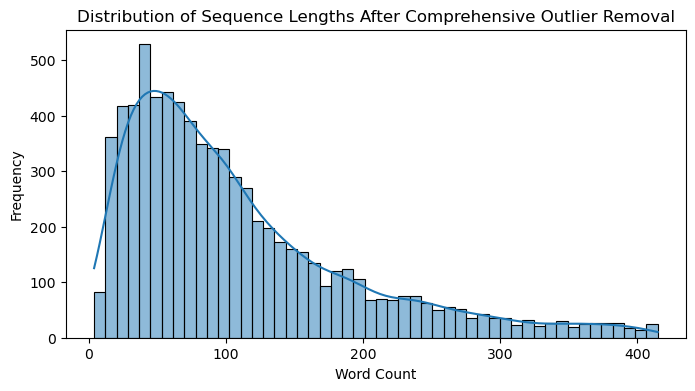

In [26]:
# Calculate a statistical upper bound (e.g., the 95th percentile)
upper_threshold = int(np.percentile(df_filtered['word_count'], 95))
print(f"95th Percentile Sequence Length: {upper_threshold} words")

# Filter out the extreme right-tail outliers
df_filtered_final = df_filtered[df_filtered['word_count'] <= upper_threshold].copy()

print(f"Dataset size after upper-bound outlier removal: {len(df_filtered_final)}")

# Re-plot to verify the normalized distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_filtered_final['word_count'], bins=50, kde=True)
plt.title("Distribution of Sequence Lengths After Comprehensive Outlier Removal")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [27]:
from collections import Counter
import numpy as np

# 1. Label Encoding
# Map 'positive' to 1 and 'negative' to 0 for binary cross-entropy calculation
sentiment_mapping = {'positive': 1, 'negative': 0}
df_filtered_final['label'] = df_filtered_final['sentiment'].map(sentiment_mapping)

# 2. Word Encoding (Tokenization)
print("Constructing vocabulary and tokenizing reviews...")

# Concatenate all sanitized reviews to build the vocabulary corpus
all_words = ' '.join(df_filtered_final['clean_review']).split()
word_counts = Counter(all_words)

# Sort words by frequency to assign lower integers to more common words
sorted_words = sorted(word_counts, key=word_counts.get, reverse=True)

# Create a dictionary mapping words to integers. 
# Indexing starts at 1 to reserve 0 explicitly for sequence padding.
vocab_to_int = {word: idx + 1 for idx, word in enumerate(sorted_words)}

# Encode the semantic text into numerical arrays
encoded_reviews = []
for review in df_filtered_final['clean_review']:
    encoded_reviews.append([vocab_to_int[word] for word in review.split()])

# 3. Sequence Standardization (Padding)
# We utilize the optimal 95th percentile length calculated in Phase 1
sequence_length = 415 

# Initialize a foundational zero-matrix of shape (Number of Reviews, Sequence Length)
features = np.zeros((len(encoded_reviews), sequence_length), dtype=int)

# Populate the matrix with the encoded reviews (Pre-padding)
for i, row in enumerate(encoded_reviews):
    features[i, -len(row):] = np.array(row)[:sequence_length]

print(f"Total Vocabulary Size: {len(vocab_to_int)} unique tokens")
print(f"Standardized Feature Matrix Shape: {features.shape}")
print("\nSample of encoded and pre-padded features (First sequence, last 15 tokens):")
print(features[0, -15:])

Constructing vocabulary and tokenizing reviews...
Total Vocabulary Size: 39147 unique tokens
Standardized Feature Matrix Shape: (7599, 415)

Sample of encoded and pre-padded features (First sequence, last 15 tokens):
[   6 1420 5680 7392   99    1  685  455   58  140   67   17  104    9
  115]


In [28]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Define Features and Labels
X = features
y = df_filtered_final['label'].values

print("Partitioning dataset into Train, Validation, and Test subsets...")

# 2. Dataset Splitting
# First, split off 10% for the final blind Test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# Second, split the remaining 90% into Train (80% of total) and Validation (10% of total)
# 0.1111 * 0.90 is approximately 0.10
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Validation Set: {X_val.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")

# 3. Convert to PyTorch Tensors
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).float())
val_data = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val).float())
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).float())

# 4. Batch Generation
# A batch size of 50 is a computationally stable choice for sequences of length 415
batch_size = 50

# drop_last=True ensures all batches have identical dimensions, 
# preventing tensor shape mismatch errors during the forward pass.
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size, drop_last=True)
val_loader = DataLoader(val_data, shuffle=True, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_data, shuffle=True, batch_size=batch_size, drop_last=True)

print(f"\nTotal Training Batches: {len(train_loader)}")
print(f"Total Validation Batches: {len(val_loader)}")
print(f"Total Test Batches: {len(test_loader)}")

Partitioning dataset into Train, Validation, and Test subsets...
Training Set: 6079 samples
Validation Set: 760 samples
Test Set: 760 samples

Total Training Batches: 121
Total Validation Batches: 15
Total Test Batches: 15


In [ ]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Architecture Definition and Model Class
class SentimentLSTM(nn.Module):
    """
    An LSTM-based neural network architecture for binary sentiment classification.
    Incorporates embedding layers for semantic mapping and dropout for regularization.
    """
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):
        super(SentimentLSTM, self).__init__()
        self.output_size = output_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim
        
        # Maps integer tokens to dense continuous vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Core recurrent layer
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, 
                            dropout=drop_prob, batch_first=True)
        
        # Regularization to prevent overfitting on the training corpus
        self.dropout = nn.Dropout(0.3)
        
        # Final classification layer mapping hidden states to a single output node
        self.fc = nn.Linear(hidden_dim, output_size)
        self.sig = nn.Sigmoid()
        
    def forward(self, x):
        """Defines the forward pass logic of the network."""
        batch_size = x.size(0)
        
        # Generate embeddings
        embeds = self.embedding(x)
        
        # Pass through LSTM
        lstm_out, hidden = self.lstm(embeds)
        
        # Isolate the output from the final temporal step of the sequence
        # (This is why pre-padding in Phase 2 was mathematically vital)
        lstm_out = lstm_out[:, -1, :] 
        
        # Apply dropout and pass through the dense layer
        out = self.dropout(lstm_out)
        out = self.fc(out)
        
        # Squash output to a probability between 0 and 1
        sig_out = self.sig(out)
        return sig_out

# 2. Network Instantiation
# The +1 accounts for the explicit 0-index used for sequence padding
vocab_size = len(vocab_to_int) + 1 
output_size = 1
embedding_dim = 128  # High dimensionality to capture complex semantic relationships
hidden_dim = 256     # Number of features in the hidden state
n_layers = 2         # Stacked LSTMs for deeper feature extraction

model = SentimentLSTM(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)

# Define Hyperparameters and Optimization Strategy
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model Architecture Initialized:")
print(model)
print("-" * 50)

# 3. Model Training Algorithm
epochs = 4
clip = 5 # Gradient clipping threshold to prevent exploding gradients

print("Commencing Model Training Phase...")
model.train()

for e in range(epochs):
    epoch_losses = []
    
    for inputs, labels in train_loader:
        # Zero the accumulated gradients
        model.zero_grad()
        
        # Forward pass
        output = model(inputs)
        
        # Compute loss
        loss = criterion(output.squeeze(), labels)
        epoch_losses.append(loss.item())
        
        # Backward pass (Backpropagation through time)
        loss.backward()
        
        # Clip gradients to maintain network stability
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        # Update weights
        optimizer.step()
        
    # Validation step at the end of each epoch
    model.eval()
    val_losses = []
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_output = model(val_inputs)
            val_loss = criterion(val_output.squeeze(), val_labels)
            val_losses.append(val_loss.item())
            
    print(f"Epoch: {e+1}/{epochs} | "
          f"Training Loss: {np.mean(epoch_losses):.4f} | "
          f"Validation Loss: {np.mean(val_losses):.4f}")
    
    model.train() # Return to training mode for the next epoch

print("-" * 50)

# 4. Empirical Testing Phase
print("Evaluating Generalization Capability on Unseen Test Data...")
model.eval()
num_correct = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        output = model(inputs)
        
        # Round probabilities to discrete binary predictions (0 or 1)
        pred = torch.round(output.squeeze()) 
        
        # Compute exact matches against the ground-truth labels
        correct_tensor = pred.eq(labels.view_as(pred))
        correct = np.squeeze(correct_tensor.numpy())
        num_correct += np.sum(correct)

# Calculate final deterministic accuracy
test_acc = num_correct / len(test_loader.dataset)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Model Architecture Initialized:
SentimentLSTM(
  (embedding): Embedding(39148, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)
--------------------------------------------------
Commencing Model Training Phase...
Epoch: 1/4 | Training Loss: 0.6541 | Validation Loss: 0.6015
Epoch: 2/4 | Training Loss: 0.5645 | Validation Loss: 0.5891
Epoch: 3/4 | Training Loss: 0.4850 | Validation Loss: 0.5415
Epoch: 4/4 | Training Loss: 0.3821 | Validation Loss: 0.6080
--------------------------------------------------
Evaluating Generalization Capability on Unseen Test Data...
Final Test Accuracy: 73.42%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Advanced Architecture Definition (BiLSTM)
class SentimentBiLSTM(nn.Module):
    """
    A Bidirectional LSTM neural network architecture.
    Processes sequences in both forward and backward directions to maximize 
    contextual feature extraction before binary classification.
    """
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):
        super(SentimentBiLSTM, self).__init__()
        self.output_size = output_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Architectural Upgrade: bidirectional=True
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, 
                            dropout=drop_prob, batch_first=True, 
                            bidirectional=True)
        
        self.dropout = nn.Dropout(0.3)
        
        # Because the network is bidirectional, the final hidden state concatenates 
        # both directions. Therefore, the input features to the linear layer must be doubled.
        self.fc = nn.Linear(hidden_dim * 2, output_size)
        self.sig = nn.Sigmoid()
        
    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, hidden = self.lstm(embeds)
        
        # Isolate the hidden states from the tuple: (hidden_state, cell_state)
        # hidden[0] shape: (num_layers * num_directions, batch_size, hidden_dim)
        hidden_state = hidden[0]
        
        # Extract the final forward and backward states from the top layer of the network
        hidden_forward = hidden_state[-2, :, :]
        hidden_backward = hidden_state[-1, :, :]
        
        # Concatenate the directional states mathematically: h_t = [h_forward ⊕ h_backward]
        concat_hidden = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        out = self.dropout(concat_hidden)
        out = self.fc(out)
        sig_out = self.sig(out)
        
        return sig_out

# 2. Network Instantiation
vocab_size = len(vocab_to_int) + 1 
output_size = 1
embedding_dim = 64
hidden_dim = 64
n_layers = 2        

model = SentimentBiLSTM(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)

# 3. Advanced Optimization Strategy
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) 

# Learning Rate Scheduler: Reduces LR by a factor of 0.1 if validation loss plateaus for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

print("BiLSTM Architecture Initialized:")
print(model)
print("-" * 50)

# 4. Extended Training Loop with Dynamic Scheduling
epochs = 15 # Extended to allow full mathematical convergence
clip = 5 
best_val_loss = float('inf')

print("Commencing BiLSTM Model Training Phase...")
model.train()

for e in range(epochs):
    epoch_losses = []
    
    for inputs, labels in train_loader:
        model.zero_grad()
        output = model(inputs)
        loss = criterion(output.squeeze(), labels)
        epoch_losses.append(loss.item())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        
    model.eval()
    val_losses = []
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_output = model(val_inputs)
            val_loss = criterion(val_output.squeeze(), val_labels)
            val_losses.append(val_loss.item())
            
    current_val_loss = np.mean(val_losses)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch: {e+1:02d}/{epochs} | "
          f"LR: {current_lr:.6f} | "
          f"Training Loss: {np.mean(epoch_losses):.4f} | "
          f"Validation Loss: {current_val_loss:.4f}")
    
    # Step the scheduler to monitor the validation loss trajectory
    scheduler.step(current_val_loss)
    
    # Early Stopping Checkpoint Protocol
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model.state_dict(), 'best_sentiment_model_bilstm.pt')
        
    model.train() 

print("-" * 50)

# 5. Final Empirical Testing
print("Evaluating BiLSTM Generalization Capability on Unseen Test Data...")
model.load_state_dict(torch.load('best_sentiment_model_bilstm.pt'))
model.eval()
num_correct = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        output = model(inputs)
        pred = torch.round(output.squeeze()) 
        correct_tensor = pred.eq(labels.view_as(pred))
        correct = np.squeeze(correct_tensor.numpy())
        num_correct += np.sum(correct)

test_acc = num_correct / len(test_loader.dataset)
print(f"Final BiLSTM Test Accuracy: {test_acc*100:.2f}%")

BiLSTM Architecture Initialized:
SentimentBiLSTM(
  (embedding): Embedding(39148, 64)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sig): Sigmoid()
)
--------------------------------------------------
Commencing BiLSTM Model Training Phase...
Epoch: 01/15 | LR: 0.001000 | Training Loss: 0.6777 | Validation Loss: 0.6713
Epoch: 02/15 | LR: 0.001000 | Training Loss: 0.6279 | Validation Loss: 0.6394
Epoch: 03/15 | LR: 0.001000 | Training Loss: 0.5582 | Validation Loss: 0.5742
Epoch: 04/15 | LR: 0.001000 | Training Loss: 0.4971 | Validation Loss: 0.5435
Epoch: 05/15 | LR: 0.001000 | Training Loss: 0.4298 | Validation Loss: 0.5283
Epoch: 06/15 | LR: 0.001000 | Training Loss: 0.3815 | Validation Loss: 0.5164
Epoch: 07/15 | LR: 0.001000 | Training Loss: 0.3202 | Validation Loss: 0.6534
Epoch: 08/15 | LR: 0.001000 | Training Loss: 0.2551 | Validation

C:\Users\murii\AppData\Local\Temp\ipykernel_12212\1647839585.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_sentiment_model_bil

Final BiLSTM Test Accuracy: 77.50%


In [22]:
import urllib.request
import zipfile
import os

# Define your specific Windows paths
downloads_dir = r"C:\Users\murii\Downloads"
zip_path = os.path.join(downloads_dir, "glove.6B.zip")
txt_file_path = os.path.join(downloads_dir, "glove.6B.100d.txt")

if not os.path.exists(txt_file_path):
    print("Downloading GloVe vectors from Stanford NLP...")
    print("Please wait. This is an 822MB file and may take a few minutes depending on your internet connection.")
    
    # Download the dataset from Stanford University
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete. Extracting the archive...")
    
    # Extract the downloaded zip file directly into your Downloads folder
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(downloads_dir)
        
    # Optional clean-up: delete the heavy zip file to save hard drive space
    os.remove(zip_path)
    print(f"Extraction complete! The file is now ready at: {txt_file_path}")
else:
    print(f"The file already exists and is ready at: {txt_file_path}")

The file already exists and is ready at: C:\Users\murii\Downloads\glove.6B.100d.txt


In [29]:
import torch
import numpy as np

def load_glove_embeddings(glove_file_path, vocab_to_int, embedding_dim=100):
    """
    Parses a pre-trained GloVe text file and constructs an embedding matrix 
    aligned with the project's tokenized vocabulary dictionary.
    """
    print("Loading pre-trained GloVe vectors into memory...")
    embeddings_index = {}
    
    # Read the GloVe file line by line
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
            
    vocab_size = len(vocab_to_int) + 1  # +1 for the 0 padding index
    
    # Initialize an embedding matrix filled with zeros (or small random values)
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype='float32')
    
    matched_words = 0
    for word, i in vocab_to_int.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Words found in the GloVe index take the pre-trained vector
            embedding_matrix[i] = embedding_vector
            matched_words += 1
        else:
            # Out-of-vocabulary (OOV) words are initialized with random uniform noise
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
            
    print(f"Embedding matrix constructed successfully.")
    print(f"Vocabulary matches in GloVe: {matched_words}/{len(vocab_to_int)}")
    
    return torch.tensor(embedding_matrix, dtype=torch.float32)

# Path to your downloaded GloVe file (e.g., 100-dimensional vectors)
glove_path = r"C:\Users\murii\Downloads\glove.6B.100d.txt"
embedding_dim = 100 # Must match the dimension of the chosen GloVe file

# Generate the pre-trained weight matrix
pretrained_weights = load_glove_embeddings(glove_path, vocab_to_int, embedding_dim=embedding_dim)

Loading pre-trained GloVe vectors into memory...
Embedding matrix constructed successfully.
Vocabulary matches in GloVe: 29131/39147


In [55]:
# 1. Define the network hyperparameters
vocab_size = len(vocab_to_int) + 1 
output_size = 1
embedding_dim = 100  # Must match the 100d GloVe vectors we downloaded
hidden_dim = 128     # Expanded capacity for richer vector representations
n_layers = 2        

# 2. Initialize the model with the defined parameters
model = GloVeBiLSTM(
    vocab_size=vocab_size, 
    output_size=output_size, 
    embedding_dim=embedding_dim, 
    hidden_dim=hidden_dim, 
    n_layers=n_layers, 
    pretrained_weights=pretrained_weights, 
    freeze_embeddings=False 
)

print("GloVe BiLSTM Architecture Successfully Initialized!")

GloVe BiLSTM Architecture Successfully Initialized!


In [58]:
import torch
import torch.optim as optim
import numpy as np

# 1. Instantiate the GloVe-backed BiLSTM
vocab_size = len(vocab_to_int) + 1 
output_size = 1
hidden_dim = 128  # Expanded capacity to handle richer vector representations
n_layers = 2        

# Initialize the model with the corrected parameter name
model = GloVeBiLSTM(
    vocab_size=vocab_size, 
    output_size=output_size, 
    embedding_dim=embedding_dim, 
    hidden_dim=hidden_dim, 
    n_layers=n_layers, 
    pretrained_weights=pretrained_weights, # Corrected parameter
    freeze_embeddings=False # Allow fine-tuning on the domain corpus
)

# 2. Optimization Strategy with Weight Decay and Dynamic Learning Rate Scheduling
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

print("GloVe BiLSTM Architecture Initialized:")
print(model)
print("-" * 50)

# 3. Training Loop with Early Stopping Protocol
epochs = 15
clip = 5 
best_val_loss = float('inf')

print("Commencing GloVe-Enhanced Model Training...")
model.train()

for e in range(epochs):
    epoch_losses = []
    
    for inputs, labels in train_loader:
        model.zero_grad()
        output = model(inputs)
        loss = criterion(output.squeeze(), labels)
        epoch_losses.append(loss.item())
        loss.backward()
        import torch.nn as nn # Ensure nn is available for gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        
    model.eval()
    val_losses = []
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_output = model(val_inputs)
            val_loss = criterion(val_output.squeeze(), val_labels)
            val_losses.append(val_loss.item())
            
    current_val_loss = np.mean(val_losses)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch: {e+1:02d}/{epochs} | "
          f"LR: {current_lr:.6f} | "
          f"Training Loss: {np.mean(epoch_losses):.4f} | "
          f"Validation Loss: {current_val_loss:.4f}")
    
    scheduler.step(current_val_loss)
    
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model.state_dict(), 'best_sentiment_model_glove.pt')
        
    model.train() 

print("-" * 50)

# 4. Final Empirical Evaluation on Test Data
print("Evaluating GloVe BiLSTM Generalization Capability...")
# Load the best saved weights from training
model.load_state_dict(torch.load('best_sentiment_model_glove.pt'))
model.eval()
num_correct = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        output = model(inputs)
        pred = torch.round(output.squeeze()) 
        correct_tensor = pred.eq(labels.view_as(pred))
        correct = np.squeeze(correct_tensor.numpy())
        num_correct += np.sum(correct)

test_acc = num_correct / len(test_loader.dataset)
print(f"Final GloVe-Enhanced Test Accuracy: {test_acc*100:.2f}%")

GloVe BiLSTM Architecture Initialized:
GloVeBiLSTM(
  (embedding): Embedding(39148, 100)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)
--------------------------------------------------
Commencing GloVe-Enhanced Model Training...
Epoch: 01/15 | LR: 0.001000 | Training Loss: 0.6712 | Validation Loss: 0.6154
Epoch: 02/15 | LR: 0.001000 | Training Loss: 0.5576 | Validation Loss: 0.4899
Epoch: 03/15 | LR: 0.001000 | Training Loss: 0.4677 | Validation Loss: 0.4994
Epoch: 04/15 | LR: 0.001000 | Training Loss: 0.3553 | Validation Loss: 0.5266
Epoch: 05/15 | LR: 0.001000 | Training Loss: 0.2532 | Validation Loss: 0.5783
Epoch: 06/15 | LR: 0.000100 | Training Loss: 0.1429 | Validation Loss: 0.5580
Epoch: 07/15 | LR: 0.000100 | Training Loss: 0.1209 | Validation Loss: 0.5911
Epoch: 08/15 | LR: 0.000100 | Training Loss: 0.1066 | Val

C:\Users\murii\AppData\Local\Temp\ipykernel_22276\4194520805.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_sentiment_model_glov

Final GloVe-Enhanced Test Accuracy: 74.21%


In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# A. Enforce Algorithmic Reproducibility 
# Secures a static random seed to ensure consistent weight initialization across runs
torch.manual_seed(42)
np.random.seed(42)

# 1. Hyperparameter Definition & Model Instantiation
vocab_size = len(vocab_to_int) + 1 
output_size = 1
embedding_dim = 100  # Matched to the extracted 100d GloVe vectors
hidden_dim = 128     # Maintains sufficient representational capacity
n_layers = 2        

model = GloVeBiLSTM(
    vocab_size=vocab_size, 
    output_size=output_size, 
    embedding_dim=embedding_dim, 
    hidden_dim=hidden_dim, 
    n_layers=n_layers, 
    pretrained_weights=pretrained_weights, 
    freeze_embeddings=True # CRITICAL: Freezes the semantic matrix to prevent overfitting
)

# 2. Refined Optimization Strategy 
criterion = nn.BCELoss()
# Reduced learning rate mitigates aggressive gradient steps during early epochs
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Optimized GloVe BiLSTM Architecture Initialized.")
print("-" * 50)

# 3. Training Loop with Early Stopping Protocol
epochs = 10
clip = 5 
best_val_loss = float('inf')

print("Commencing Model Training Phase...")
model.train()

for e in range(epochs):
    epoch_losses = []
    
    for inputs, labels in train_loader:
        model.zero_grad()
        output = model(inputs)
        loss = criterion(output.squeeze(), labels)
        epoch_losses.append(loss.item())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        
    # Validation Phase
    model.eval()
    val_losses = []
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_output = model(val_inputs)
            val_loss = criterion(val_output.squeeze(), val_labels)
            val_losses.append(val_loss.item())
            
    current_val_loss = np.mean(val_losses)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch: {e+1:02d}/{epochs} | "
          f"LR: {current_lr:.6f} | "
          f"Training Loss: {np.mean(epoch_losses):.4f} | "
          f"Validation Loss: {current_val_loss:.4f}")
    
    scheduler.step(current_val_loss)
    
    # Early Stopping Checkpoint: Saves weights only when validation loss improves
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model.state_dict(), 'best_sentiment_model_glove.pt')
        
    model.train() 

print("-" * 50)

# 4. Final Empirical Evaluation on Test Data
print("Evaluating Generalization Capability on Unseen Test Data...")

# Load the optimal saved weights (weights_only=True resolves PyTorch FutureWarnings)
model.load_state_dict(torch.load('best_sentiment_model_glove.pt', weights_only=True))
model.eval()
num_correct = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        output = model(inputs)
        pred = torch.round(output.squeeze()) 
        correct_tensor = pred.eq(labels.view_as(pred))
        correct = np.squeeze(correct_tensor.numpy())
        num_correct += np.sum(correct)

test_acc = num_correct / len(test_loader.dataset)
print(f"Final Optimized Test Accuracy: {test_acc*100:.2f}%")

Optimized GloVe BiLSTM Architecture Initialized.
--------------------------------------------------
Commencing Model Training Phase...
Epoch: 01/10 | LR: 0.000500 | Training Loss: 0.6379 | Validation Loss: 0.5274
Epoch: 02/10 | LR: 0.000500 | Training Loss: 0.4955 | Validation Loss: 0.4853
Epoch: 03/10 | LR: 0.000500 | Training Loss: 0.4454 | Validation Loss: 0.4985
Epoch: 04/10 | LR: 0.000500 | Training Loss: 0.4342 | Validation Loss: 0.4752
Epoch: 05/10 | LR: 0.000500 | Training Loss: 0.4157 | Validation Loss: 0.4844
Epoch: 06/10 | LR: 0.000500 | Training Loss: 0.4036 | Validation Loss: 0.4654
Epoch: 07/10 | LR: 0.000500 | Training Loss: 0.3885 | Validation Loss: 0.4549
Epoch: 08/10 | LR: 0.000500 | Training Loss: 0.3909 | Validation Loss: 0.4708
Epoch: 09/10 | LR: 0.000500 | Training Loss: 0.3834 | Validation Loss: 0.4439
Epoch: 10/10 | LR: 0.000500 | Training Loss: 0.3787 | Validation Loss: 0.4392
--------------------------------------------------
Evaluating Generalization Capabili

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

# A. Enforce Algorithmic Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. Advanced Architecture: BiLSTM with Self-Attention
class GloVeAttentionBiLSTM(nn.Module):
    """
    A Bidirectional LSTM enhanced with a self-attention mechanism.
    Dynamically weights temporal hidden states to isolate high-polarity sentiment features.
    """
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, pretrained_weights, drop_prob=0.5, freeze_embeddings=True):
        super(GloVeAttentionBiLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        
        # Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(pretrained_weights)
        self.embedding.weight.requires_grad = not freeze_embeddings
        
        # BiLSTM Layer
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, 
                            dropout=drop_prob, batch_first=True, 
                            bidirectional=True)
        
        # Attention Layer: Maps the bidirectional hidden state to a single scalar score
        self.attention_layer = nn.Linear(hidden_dim * 2, 1)
        
        # Regularization & Classification
        self.dropout = nn.Dropout(0.4) # Slightly increased dropout for attention stability
        self.fc = nn.Linear(hidden_dim * 2, output_size)
        self.sig = nn.Sigmoid()
        
    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        embeds = self.embedding(x)
        
        # lstm_out shape: (batch_size, sequence_length, hidden_dim * 2)
        lstm_out, _ = self.lstm(embeds) 
        
        # --- Attention Mechanism ---
        # 1. Calculate attention scores: (batch_size, sequence_length, 1)
        attn_scores = self.attention_layer(lstm_out) 
        
        # 2. Squeeze to (batch_size, sequence_length) and apply softmax
        attn_scores = torch.squeeze(attn_scores, 2)
        attn_weights = F.softmax(attn_scores, dim=1) 
        
        # 3. Apply weights to hidden states (batch matrix multiplication)
        # Reshape weights to (batch_size, 1, sequence_length)
        attn_weights = torch.unsqueeze(attn_weights, 1)
        
        # Context vector shape: (batch_size, 1, hidden_dim * 2)
        context_vector = torch.bmm(attn_weights, lstm_out) 
        
        # Squeeze down to (batch_size, hidden_dim * 2) for the fully connected layer
        context_vector = torch.squeeze(context_vector, 1)
        
        out = self.dropout(context_vector)
        out = self.fc(out)
        sig_out = self.sig(out)
        
        return sig_out

# 2. Hyperparameter Definition & Model Instantiation
vocab_size = len(vocab_to_int) + 1 
output_size = 1
embedding_dim = 100  
hidden_dim = 128     
n_layers = 2        

model = GloVeAttentionBiLSTM(
    vocab_size=vocab_size, 
    output_size=output_size, 
    embedding_dim=embedding_dim, 
    hidden_dim=hidden_dim, 
    n_layers=n_layers, 
    pretrained_weights=pretrained_weights, 
    freeze_embeddings=True 
)

# 3. Refined Optimization Strategy 
criterion = nn.BCELoss()
# Maintained low learning rate for smooth convergence
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("Optimized Attention-BiLSTM Architecture Initialized.")
print("-" * 50)

# 4. Training Loop with Early Stopping Protocol
epochs = 15
clip = 5 
best_val_loss = float('inf')

print("Commencing Attention Model Training Phase...")
model.train()

for e in range(epochs):
    epoch_losses = []
    
    for inputs, labels in train_loader:
        model.zero_grad()
        output = model(inputs)
        loss = criterion(output.squeeze(), labels)
        epoch_losses.append(loss.item())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        
    model.eval()
    val_losses = []
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_output = model(val_inputs)
            val_loss = criterion(val_output.squeeze(), val_labels)
            val_losses.append(val_loss.item())
            
    current_val_loss = np.mean(val_losses)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch: {e+1:02d}/{epochs} | "
          f"LR: {current_lr:.6f} | "
          f"Training Loss: {np.mean(epoch_losses):.4f} | "
          f"Validation Loss: {current_val_loss:.4f}")
    
    scheduler.step(current_val_loss)
    
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save(model.state_dict(), 'best_sentiment_model_attention.pt')
        
    model.train() 

print("-" * 50)

# 5. Final Empirical Evaluation on Test Data
print("Evaluating Attention Model Generalization...")

model.load_state_dict(torch.load('best_sentiment_model_attention.pt', weights_only=True))
model.eval()
num_correct = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        output = model(inputs)
        pred = torch.round(output.squeeze()) 
        correct_tensor = pred.eq(labels.view_as(pred))
        correct = np.squeeze(correct_tensor.numpy())
        num_correct += np.sum(correct)

test_acc = num_correct / len(test_loader.dataset)
print(f"Final Attention-Enhanced Test Accuracy: {test_acc*100:.2f}%")

Optimized Attention-BiLSTM Architecture Initialized.
--------------------------------------------------
Commencing Attention Model Training Phase...
Epoch: 01/15 | LR: 0.000500 | Training Loss: 0.6834 | Validation Loss: 0.6279
Epoch: 02/15 | LR: 0.000500 | Training Loss: 0.5382 | Validation Loss: 0.5712
Epoch: 03/15 | LR: 0.000500 | Training Loss: 0.4568 | Validation Loss: 0.4727
Epoch: 04/15 | LR: 0.000500 | Training Loss: 0.4218 | Validation Loss: 0.4379
Epoch: 05/15 | LR: 0.000500 | Training Loss: 0.4274 | Validation Loss: 0.4574
Epoch: 06/15 | LR: 0.000500 | Training Loss: 0.3976 | Validation Loss: 0.4397
Epoch: 07/15 | LR: 0.000500 | Training Loss: 0.3882 | Validation Loss: 0.4254
Epoch: 08/15 | LR: 0.000500 | Training Loss: 0.3906 | Validation Loss: 0.4175
Epoch: 09/15 | LR: 0.000500 | Training Loss: 0.3666 | Validation Loss: 0.4222
Epoch: 10/15 | LR: 0.000500 | Training Loss: 0.3738 | Validation Loss: 0.4411
Epoch: 11/15 | LR: 0.000500 | Training Loss: 0.3534 | Validation Loss: 

In [63]:
import gradio as gr
import torch
import numpy as np
import re
import traceback

# 1. Define the Inference Preprocessing Function
def predict_sentiment(review_text, model, vocab_to_int, sequence_length=415):
    """
    Transforms raw input text into standardized tensors, executes a forward 
    pass through the trained LSTM, and returns a binary classification.
    """
    model.eval()
    
    # String sanitization
    clean_rev = review_text.lower()
    clean_rev = re.sub(r'[^a-z0-9\s]', '', clean_rev)
    clean_rev = re.sub(r'\s+', ' ', clean_rev).strip()
    
    # Tokenize utilizing the established vocabulary dictionary
    encoded = [vocab_to_int.get(word, 0) for word in clean_rev.split()]
    
    # Sequence Standardization (Pre-padding)
    features = np.zeros((1, sequence_length), dtype=int)
    features[0, -len(encoded):] = np.array(encoded)[:sequence_length]
    
    # Tensor Conversion
    feature_tensor = torch.from_numpy(features)
    
    # Execute Model Inference
    with torch.no_grad():
        output = model(feature_tensor)
        prediction = torch.round(output.squeeze()).item()
        
    # Output formatting
    if prediction == 1.0:
        return f"Input: '{review_text}'\nOutput: Positive review"
    else:
        return f"Input: '{review_text}'\nOutput: Negative review"

# 2. Interactive Browser-Based Deployment 
def browser_inference(user_input, history):
    """
    Wrapper function connecting the Gradio UI with the PyTorch model.
    Maintains a stateful history of the last 10 inputs and outputs.
    """
    try:
        # Safety Check: Ensure history is initialized
        if history is None:
            history = []
            
        # Validate input length
        if len(user_input.split()) < 3:
            current_output = f"Input: '{user_input}'\nOutput: Error - Input too short. Please provide a more detailed review."
        else:
            # Execute the prediction function (now safely defined above)
            current_output = predict_sentiment(user_input, model, vocab_to_int)
        
        # Prepend the newest output and enforce the 10-output limit
        history.insert(0, current_output)
        history = history[:10]
        
        display_text = "\n----------------------------------------\n".join(history)
        return display_text, history
        
    except Exception as e:
        error_message = f"SYSTEM ERROR ENCOUNTERED:\n{str(e)}\n\nDiagnostic Traceback:\n{traceback.format_exc()}"
        if history is None:
            history = []
        return error_message, history

print("\n--- Launching Unified Browser Deployment ---")

interface = gr.Interface(
    fn=browser_inference,
    inputs=[
        gr.Textbox(lines=3, placeholder="Enter a product review (minimum 3 words)...", label="Product Review Input"),
        gr.State([])  
    ],
    outputs=[
        gr.Textbox(lines=15, label="Sentiment Classification Output (Last 10 Results)"),
        gr.State()    
    ],
    title="Intelligent Systems: NLP Sentiment Analysis",
    description="Enter a sample statement to execute the neural network inference. The system will retain and display a running log of your last 10 evaluations."
)

interface.launch(inbrowser=True)


--- Launching Unified Browser Deployment ---
* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
